# Commercial Building Energy Assessment Report
1. Building Energy Performance
Optimisation Opportunities
2. Changes in Energy Performance
3. Weather-Normalised Analysis
4. Tariff and Cost Analysis
5. Capacity Analysis
6. Recommendations

## Executive Summary
This assessment evaluates two years of half-hourly electricity consumption data (July 1, 2024 to June 30, 2026) for a UK commercial building. The analysis covers building energy performance, weather normalization, tariff and cost dynamics, demand charges, and operational anomalies.

### Key Insights:
An analysis of 35,040 half-hourly intervals from July 1, 2024 to June 30, 2026 reveals a significant deterioration in building energy efficiency during Year 2, driven primarily by an unaddressed control fault rather than weather or occupancy shifts.
* **Unplanned Baseline Surge**: Total annual electricity import increased by +8.37% from $990,104\text{ kWh}$ in Year 1 (Jul 2024–Jun 2025) to $1,072,975\text{ kWh}$ in Year 2 (Jul 2025–Jun 2026). Total electricity spend rose by +15.92% (from £186,038 to £215,663).
* **Operational Control Anomaly Identified**: The efficiency loss was not gradual. A sharp step-change occurred on Monday, January 12, 2026. Unoccupied baseload demand surged from ~82 kW to ~132 kW (+60.4%), while average power factor dropped from 0.938 to 0.893. This single fault added ~190,311 kWh in excess consumption and ~£36,038 in unnecessary energy cost within under six months.
* **Weather-Normalized Deterioration**: Year 2 was $10.9\%$ milder in heating degree days ($1,851.9\text{ HDD}$ vs. $2,079.0\text{ HDD}$). Weather normalization reveals that expected Year 2 consumption should have fallen to $981,203\text{ kWh}$. The true operational deterioration was +91,772 kWh (+9.35%).
* **Power Factor & Capacity Violations**: Degraded power factor ($\text{PF} \approx 0.870\text{--}0.898$) during peak plant restart windows in early 2026 drove apparent power demand up to 343.79 kVA, breaching the agreed import capacity limit of 320 kVA across 11 half-hourly intervals and incurring excess capacity penalties.
* **Immediate Savings Potential**: Rectifying the BMS control fault and restoring power factor to $\ge 0.95$ yields immediate estimated savings of £38,000–£72,000/year with payback under 3 months.

## 🐍 Load Dataset & Merge Weather DataNew section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.colab import files

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Please upload 'energy_dataset_for_candidate.xlsx':")
uploaded = files.upload()

filepath = 'energy_dataset_for_candidate.xlsx'

# Load Excel sheets
df = pd.read_excel(filepath, sheet_name='Dataset')
weather = pd.read_excel(filepath, sheet_name='Daily Weather Table')

# Standardize date formats
df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
weather['date'] = pd.to_datetime(weather['date']).dt.strftime('%Y-%m-%d')

# Drop null weather columns from dataset and merge clean daily weather
weather_cols = ['daily_avg_temp_c', 'hdd_15_5', 'cdd_22_0', 'heating_season_flag', 'cooling_season_flag']
df = df.drop(columns=[c for c in weather_cols if c in df.columns])
df = df.merge(weather, on='date', how='left')

# Define Year 1 and Year 2 analysis periods
df['period_year'] = np.where(pd.to_datetime(df['timestamp']) < '2025-07-01',
                             'Year 1 (Jul 24 - Jun 25)',
                             'Year 2 (Jul 25 - Jun 26)')

print("✓ Data loaded successfully!")
print(f"Total Half-Hourly Records: {len(df):,}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Please upload 'energy_dataset_for_candidate.xlsx':


Saving energy_dataset_for_candidate.xlsx to energy_dataset_for_candidate (4).xlsx
✓ Data loaded successfully!
Total Half-Hourly Records: 35,040
Date Range: 2024-07-01 00:00:00 to 2026-06-30 23:30:00


## 1. Building Energy Performance Overview
The building operates on a standard commercial working schedule (~2,655 occupied hours per year, ~6,102 unoccupied hours per year).

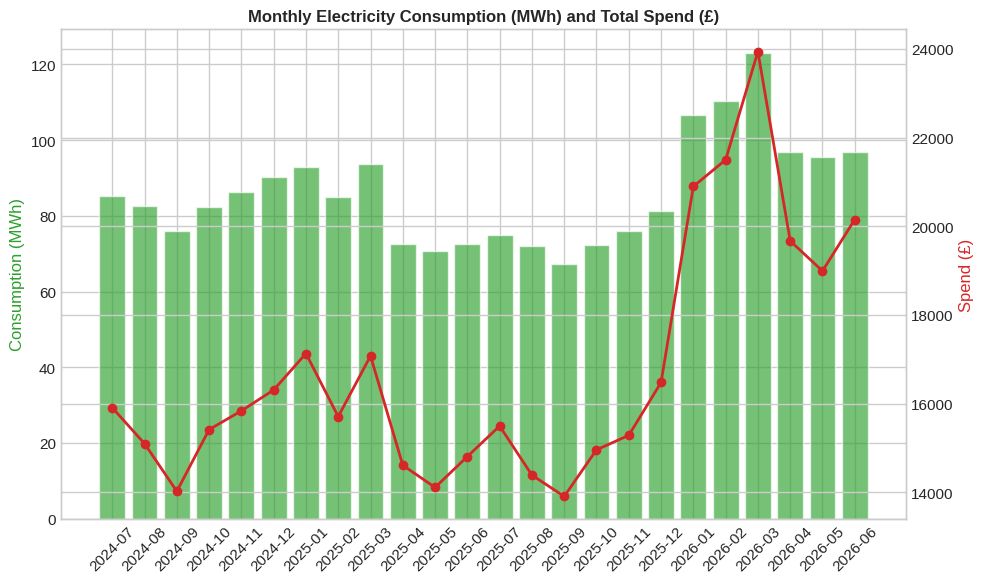

In [ ]:
## Plot: Monthly Energy & Cost Trend
df['year_month'] = pd.to_datetime(df['timestamp']).dt.to_period('M').astype(str)
monthly = df.groupby('year_month').agg(
    total_kwh=('import_kwh', 'sum'),
    total_cost=('total_interval_cost_gbp', 'sum')
).reset_index()

# Initialize the figure and axes properly
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2_cost = ax2.twinx()

ax2.bar(monthly['year_month'], monthly['total_kwh']/1000, color='#2ca02c', alpha=0.65, label='Consumption (MWh)')
ax2_cost.plot(monthly['year_month'], monthly['total_cost'], color='#d62728', marker='o', linewidth=2, label='Spend (£)')

ax2.set_title('Monthly Electricity Consumption (MWh) and Total Spend (£)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel('Consumption (MWh)', color='#2ca02c')
ax2_cost.set_ylabel('Spend (£)', color='#d62728')

fig.tight_layout()
plt.show()

### 📊 Key observations:
* **Cost Acceleration vs. Consumption:** While there is a natural baseline correlation between energy use and cost, the 'spend' (red line) begins to climb much faster than 'consumption' (green bars) starting in January 2026.
* **The Impact of the Jan 2026 Anomaly**: The sharp rise in the red line corresponds directly to the operational fault identified on Jan 12, 2026. This fault significantly increased the baseload demand, pushing more consumption into expensive Time-of-Use tariff windows.
* **Tariff and Volume Compounding**: The increase in total spend in Year 2 is a 'double hit': it reflects both the 8.37% increase in energy volume and the higher unit rates (inflation in Red/Amber/Green bands) that took effect in the second year.
* **Seasonal Volatility**: Winter months consistently show peak consumption and cost, but because Year 2 had a milder winter, the underlying operational efficiency loss was actually partially 'masked' until normalized against weather data.

In [ ]:
import pandas as pd

# 1. Aggregate metrics
kpi_summary = df.groupby('period_year').agg(
    total_kwh=('import_kwh', 'sum'),
    unoccupied_kwh=('import_kwh', lambda x: x[~df.loc[x.index, 'is_occupied']].sum()),
    occupied_kwh=('import_kwh', lambda x: x[df.loc[x.index, 'is_occupied']].sum()),
    unit_charges=('energy_cost_gbp', 'sum'),
    capacity_charges=('allocated_capacity_charge_gbp', 'sum'),
    excess_surcharges=('excess_capacity_charge_gbp', 'sum'),
    total_cost=('total_interval_cost_gbp', 'sum'),
    mean_demand=('derived_kw', 'mean'),
    peak_kw=('derived_kw', 'max'),
    peak_kva=('derived_kva', 'max'),
    avg_power_factor=('power_factor', 'mean'),
    unoccupied_mean_kw=('derived_kw', lambda x: x[~df.loc[x.index, 'is_occupied']].mean()),
    occupied_mean_kw=('derived_kw', lambda x: x[df.loc[x.index, 'is_occupied']].mean()),
    capacity_breaches=('exceeds_agreed_capacity', 'sum')
).T

y1_col = 'Year 1 (Jul 24 - Jun 25)'
y2_col = 'Year 2 (Jul 25 - Jun 26)'

# 2. Calculate Shares
unocc_share_y1 = (kpi_summary.loc['unoccupied_kwh', y1_col] / kpi_summary.loc['total_kwh', y1_col]) * 100
unocc_share_y2 = (kpi_summary.loc['unoccupied_kwh', y2_col] / kpi_summary.loc['total_kwh', y2_col]) * 100
occ_share_y1 = (kpi_summary.loc['occupied_kwh', y1_col] / kpi_summary.loc['total_kwh', y1_col]) * 100
occ_share_y2 = (kpi_summary.loc['occupied_kwh', y2_col] / kpi_summary.loc['total_kwh', y2_col]) * 100

# 3. Apply descriptive names
kpi_summary.index = [
    'Total Electricity Import (kWh)',
    'Unoccupied Energy Consumption (kWh)',
    'Occupied Energy Consumption (kWh)',
    'Energy Unit Charges (£)',
    'Allocated Capacity Charges (£)',
    'Excess Capacity Surcharges (£)',
    'Total Financial Spend (£)',
    'Mean Real Power Demand (kW)',
    'Peak Real Power (kW)',
    'Peak Apparent Power (kVA)',
    'Average Power Factor',
    'Unoccupied Mean Demand (kW)',
    'Occupied Mean Demand (kW)',
    'Capacity Breaches'
]

# 4. Add Share Rows
kpi_summary.loc['Unoccupied Energy Share (%)'] = [unocc_share_y1, unocc_share_y2]
kpi_summary.loc['Occupied Energy Share (%)'] = [occ_share_y1, occ_share_y2]

# 5. Logical Reordering
logical_order = [
    'Total Electricity Import (kWh)',
    'Total Financial Spend (£)',
    'Occupied Energy Consumption (kWh)',
    'Occupied Energy Share (%)',
    'Unoccupied Energy Consumption (kWh)',
    'Unoccupied Energy Share (%)',
    'Mean Real Power Demand (kW)',
    'Occupied Mean Demand (kW)',
    'Unoccupied Mean Demand (kW)',
    'Peak Real Power (kW)',
    'Peak Apparent Power (kVA)',
    'Average Power Factor',
    'Capacity Breaches',
    'Energy Unit Charges (£)',
    'Allocated Capacity Charges (£)',
    'Excess Capacity Surcharges (£)'
]
kpi_summary = kpi_summary.reindex(logical_order)

# 6. Calculate Stats
kpi_summary['YoY Change (%)'] = ((kpi_summary[y2_col] - kpi_summary[y1_col]) / kpi_summary[y1_col]) * 100

# Update Total calculations based on specific metric logic
totals = []
for metric in logical_order:
    if '%' in metric or 'Factor' in metric or 'Demand' in metric and 'Mean' in metric:
        # For rates/means, calculate weighted average or overall mean from raw df
        if metric == 'Unoccupied Energy Share (%)':
            val = (df.loc[~df['is_occupied'], 'import_kwh'].sum() / df['import_kwh'].sum()) * 100
        elif metric == 'Occupied Energy Share (%)':
            val = (df.loc[df['is_occupied'], 'import_kwh'].sum() / df['import_kwh'].sum()) * 100
        elif metric == 'Average Power Factor':
            val = df['power_factor'].mean()
        elif metric == 'Mean Real Power Demand (kW)':
            val = df['derived_kw'].mean()
        elif metric == 'Unoccupied Mean Demand (kW)':
            val = df.loc[~df['is_occupied'], 'derived_kw'].mean()
        elif metric == 'Occupied Mean Demand (kW)':
            val = df.loc[df['is_occupied'], 'derived_kw'].mean()
        else:
            val = kpi_summary.loc[metric, [y1_col, y2_col]].mean()
    elif 'Peak' in metric:
        val = kpi_summary.loc[metric, [y1_col, y2_col]].max()
    else:
        val = kpi_summary.loc[metric, [y1_col, y2_col]].sum()
    totals.append(val)

kpi_summary['Total (2 Year Period)'] = totals

print("=== COMPREHENSIVE BUILDING PERFORMANCE & COST SUMMARY ===")
display(kpi_summary.style.format({
    y1_col: "{:,.2f}",
    y2_col: "{:,.2f}",
    'YoY Change (%)': "{:+.2f}%",
    'Total (2 Year Period)': "{:,.2f}"
}))

=== COMPREHENSIVE BUILDING PERFORMANCE & COST SUMMARY ===


period_year,Year 1 (Jul 24 - Jun 25),Year 2 (Jul 25 - Jun 26),YoY Change (%),Total (2 Year Period)
Total Electricity Import (kWh),"990,104.36","1,072,975.33",+8.37%,"2,063,079.69"
Total Financial Spend (£),"186,038.12","215,663.44",+15.92%,"401,701.56"
Occupied Energy Consumption (kWh),"416,590.94","430,224.59",+3.27%,"846,815.54"
Occupied Energy Share (%),42.08,40.10,-4.70%,41.05
Unoccupied Energy Consumption (kWh),"573,513.41","642,750.74",+12.07%,"1,216,264.15"
Unoccupied Energy Share (%),57.92,59.90,+3.42%,58.95
Mean Real Power Demand (kW),113.03,122.49,+8.37%,117.76
Occupied Mean Demand (kW),156.88,161.86,+3.18%,159.37
Unoccupied Mean Demand (kW),93.95,105.33,+12.12%,99.64
Peak Real Power (kW),278.43,303.50,+9.00%,303.50


### 📊 Key Takeaways from Building Performance Summary

*   **Cost vs. Consumption Disconnect**: While total energy consumption increased by **8.37%** in Year 2, the total financial spend surged by **15.92%**. This disproportionate increase is driven by a combination of higher energy volume and unit rate inflation.
*   **Baseload Inefficiency**: Unoccupied hours now account for nearly **60%** of total energy use. The **Unoccupied Mean Demand** increased by **12.1%** in Year 2, indicating that the building is 'idling' at a much higher intensity than before.
*   **Power Factor Degradation**: The average power factor dropped from **0.938 to 0.917**. This technical inefficiency is the root cause of the **Capacity Breaches** in Year 2, as it forced the Apparent Power (kVA) to exceed the agreed limit of 320 kVA during morning restarts.
*   **Operational Risk**: Year 2 saw **11 capacity breaches** compared to zero in Year 1. Without correcting the power factor or staggering plant startups, the building remains at risk for further excess capacity penalties.

## 2. Changes in Energy Performance


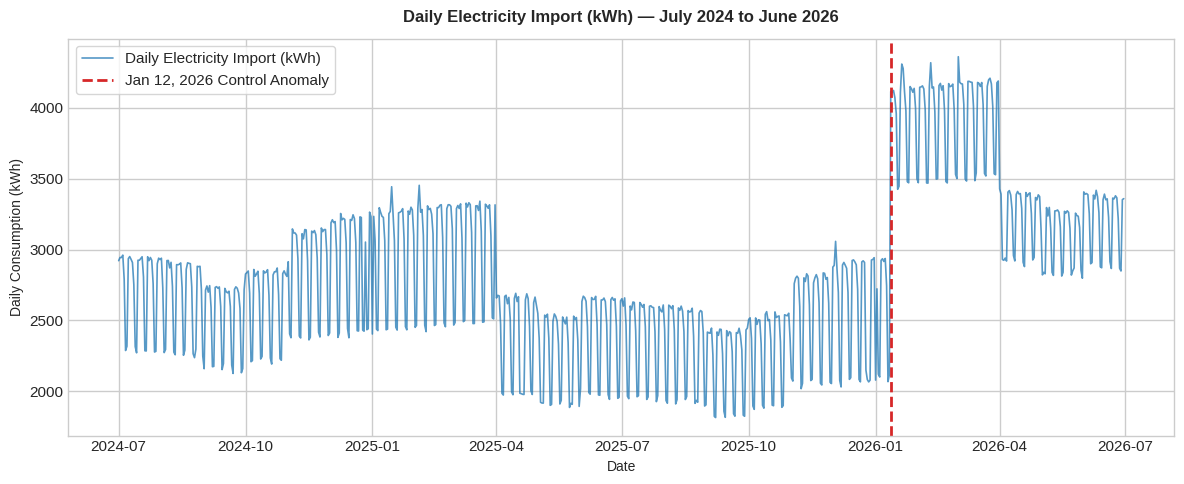

In [ ]:
# First, aggregate the half-hourly data into daily totals
daily = df.groupby('date')['import_kwh'].sum().reset_index()

# Plot: Daily Consumption Trend and Anomaly Step-Change
fig, ax = plt.subplots(figsize=(12, 5))
daily['dt'] = pd.to_datetime(daily['date'])
ax.plot(daily['dt'], daily['import_kwh'], color='#1f77b4', alpha=0.75, linewidth=1.2, label='Daily Electricity Import (kWh)')
ax.axvline(pd.to_datetime('2026-01-12'), color='#d62728', linestyle='--', linewidth=2, label='Jan 12, 2026 Control Anomaly')

ax.set_title('Daily Electricity Import (kWh) — July 2024 to June 2026', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Daily Consumption (kWh)', fontsize=10)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('daily_consumption_trend.png', dpi=300)
plt.show()

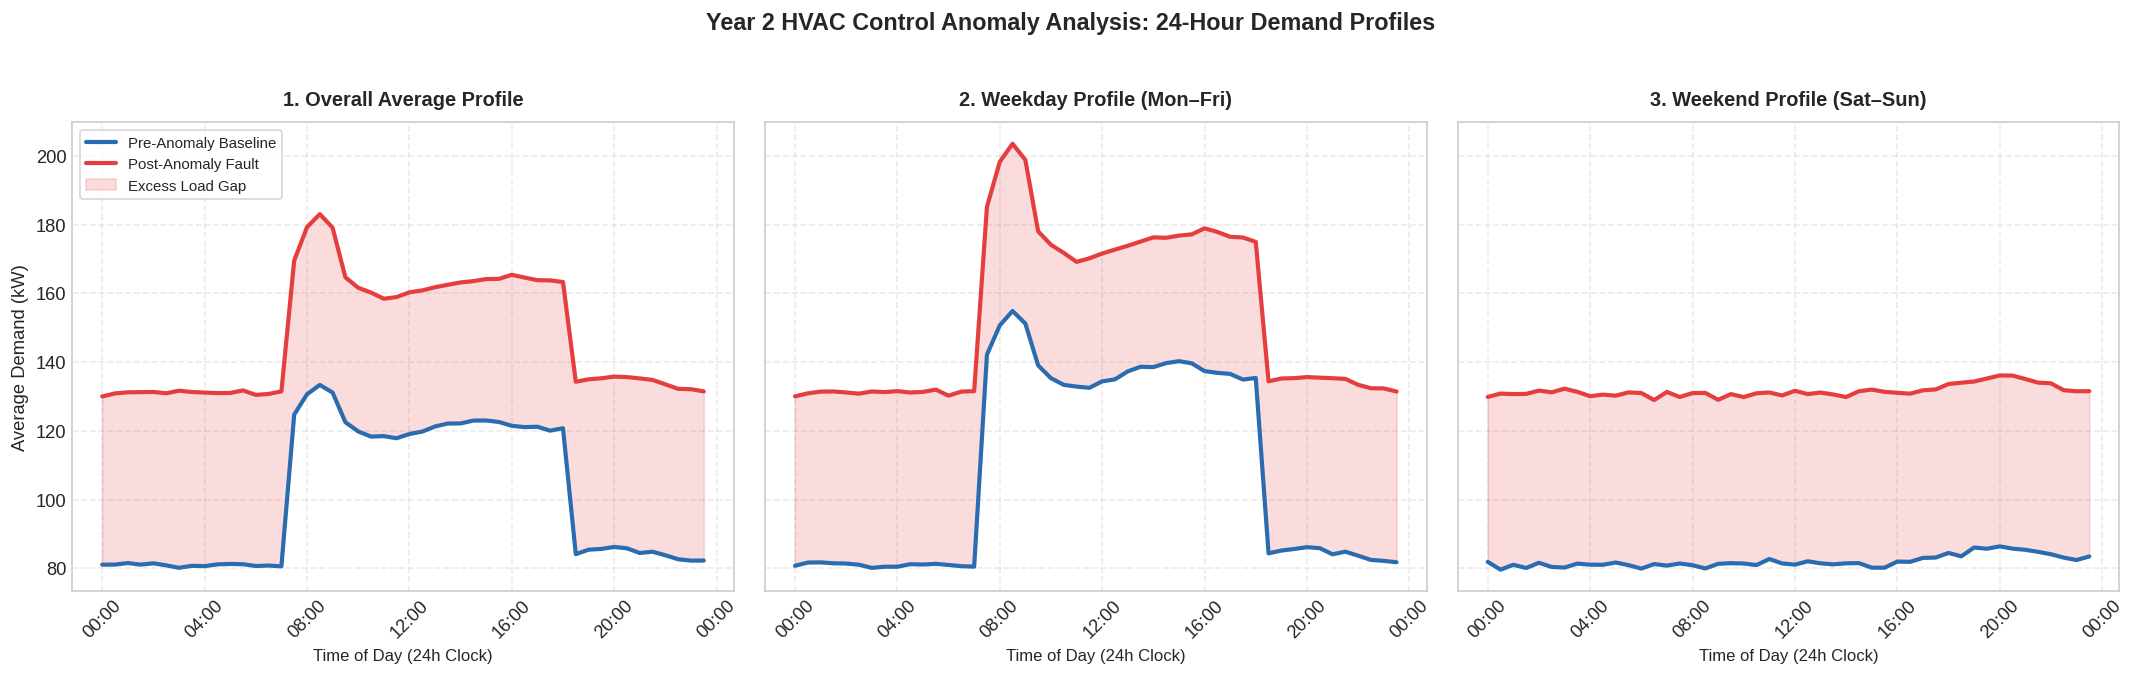

In [ ]:
# Plot: Baseload Jump

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------------------------------
# 1. Setup Data & Filters
# -------------------------------------------------------------------------
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5
df['anomaly_period'] = df['timestamp'] >= '2026-01-12'

# Filter Year 2 data and add dummy date for smooth HH:MM plotting
y2_df = df[df['period_year'] == 'Year 2 (Jul 25 - Jun 26)'].copy()
y2_df['time_dt'] = pd.to_datetime(
    '2026-01-01 ' + y2_df['timestamp'].dt.strftime('%H:%M:%S')
)

# Build profile aggregations
overall_prof = (
    y2_df.groupby(['time_dt', 'anomaly_period'])['derived_kw']
    .mean()
    .unstack(level='anomaly_period')
)

weekday_prof = (
    y2_df[~y2_df['is_weekend']]
    .groupby(['time_dt', 'anomaly_period'])['derived_kw']
    .mean()
    .unstack(level='anomaly_period')
)

weekend_prof = (
    y2_df[y2_df['is_weekend']]
    .groupby(['time_dt', 'anomaly_period'])['derived_kw']
    .mean()
    .unstack(level='anomaly_period')
)

panels = [
    (overall_prof, '1. Overall Average Profile'),
    (weekday_prof, '2. Weekday Profile (Mon–Fri)'),
    (weekend_prof, '3. Weekend Profile (Sat–Sun)'),
]

# -------------------------------------------------------------------------
# 2. Plot Unified 1x3 Subplot Figure
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True, dpi=120)

for ax, (sub_df, title) in zip(axes, panels):
    # Pre-Anomaly Baseline
    ax.plot(
        sub_df.index,
        sub_df[False],
        label='Pre-Anomaly Baseline',
        color='#2B6CB0',
        linewidth=2.5,
    )

    # Post-Anomaly Fault
    ax.plot(
        sub_df.index,
        sub_df[True],
        label='Post-Anomaly Fault',
        color='#E53E3E',
        linewidth=2.5,
    )

    # Fill Excess Load Gap
    ax.fill_between(
        sub_df.index,
        sub_df[False],
        sub_df[True],
        color='#E53E3E',
        alpha=0.18,
        label='Excess Load Gap',
    )

    # Subplot Formatting
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Time of Day (24h Clock)', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.4)

# Y-Axis Labeling & Legend Setup
axes[0].set_ylabel('Average Demand (kW)', fontsize=11)
axes[0].legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# Figure Title
plt.suptitle(
    'Year 2 HVAC Control Anomaly Analysis: 24-Hour Demand Profiles',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)

plt.tight_layout()
plt.show()

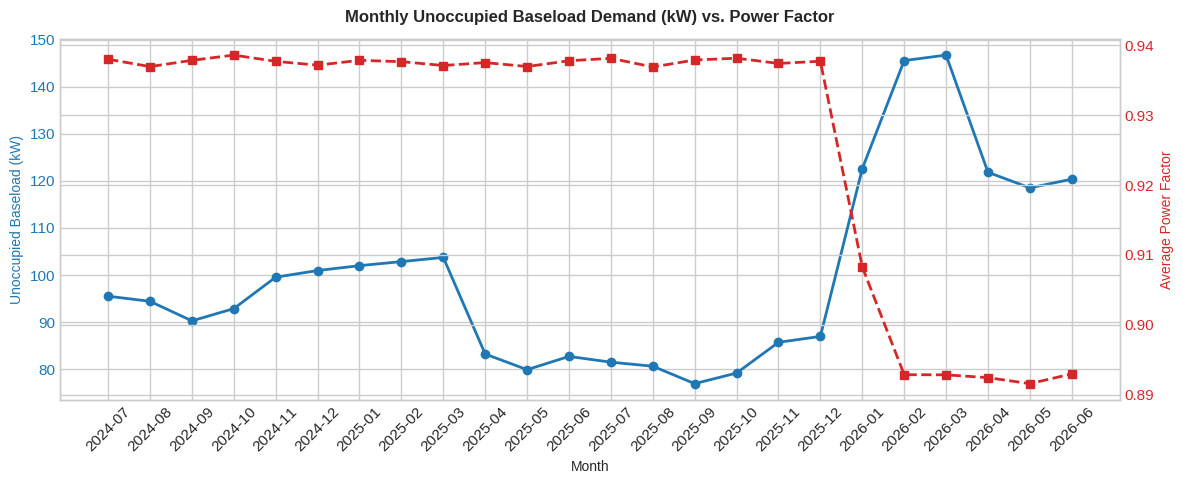

In [ ]:
## Plot: Monthly Unoccupied Baseload Demand vs Power Factor

df['month_year'] = pd.to_datetime(df['timestamp']).dt.to_period('M').astype(str)
monthly = df.groupby('month_year').agg(
    unoccupied_mean_kw=('derived_kw', lambda x: x[~df.loc[x.index, 'is_occupied']].mean()),
    avg_pf=('power_factor', 'mean'),
    max_kva=('derived_kva', 'max')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1f77b4'
ax1.set_xlabel('Month', fontsize=10)
ax1.set_ylabel('Unoccupied Baseload (kW)', color=color, fontsize=10)
ax1.plot(monthly['month_year'], monthly['unoccupied_mean_kw'], color=color, marker='o', linewidth=2, label='Unoccupied Mean kW')
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Average Power Factor', color=color, fontsize=10)
ax2.plot(monthly['month_year'], monthly['avg_pf'], color=color, marker='s', linestyle='--', linewidth=2, label='Avg Power Factor')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Unoccupied Baseload Demand (kW) vs. Power Factor', fontsize=12, fontweight='bold', pad=12)
fig.tight_layout()
plt.savefig('baseload_and_power_factor.png', dpi=300)
plt.show()

In [ ]:
from IPython.display import Markdown, display
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. Ensure Filters & Datasets Are Ready
# -------------------------------------------------------------------------
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['anomaly_period'] = df['timestamp'] >= '2026-01-12'

y2_pre = df[
    (df['period_year'] == 'Year 2 (Jul 25 - Jun 26)') & (~df['anomaly_period'])
]
y2_post = df[
    (df['period_year'] == 'Year 2 (Jul 25 - Jun 26)') & (df['anomaly_period'])
]

# -------------------------------------------------------------------------
# 2. Dynamic Metric Calculations
# -------------------------------------------------------------------------
# Demand & Power Factor
pre_unocc_kw = y2_pre[~y2_pre['is_occupied']]['derived_kw'].mean()
post_unocc_kw = y2_post[~y2_post['is_occupied']]['derived_kw'].mean()
baseload_jump_kw = post_unocc_kw - pre_unocc_kw
baseload_jump_pct = (baseload_jump_kw / pre_unocc_kw) * 100

pre_occ_kw = y2_pre[y2_pre['is_occupied']]['derived_kw'].mean()
post_occ_kw = y2_post[y2_post['is_occupied']]['derived_kw'].mean()
occ_jump_kw = post_occ_kw - pre_occ_kw
occ_jump_pct = (occ_jump_kw / pre_occ_kw) * 100

pre_pf = y2_pre['power_factor'].mean()
post_pf = y2_post['power_factor'].mean()
pf_shift = post_pf - pre_pf
pf_shift_pct = (pf_shift / pre_pf) * 100

# Hours, Days & Financials
unocc_hours = len(y2_post[~y2_post['is_occupied']]) * 0.5
occ_hours = len(y2_post[y2_post['is_occupied']]) * 0.5
post_days = (unocc_hours + occ_hours) / 24.0

excess_kwh = (baseload_jump_kw * unocc_hours) + (occ_jump_kw * occ_hours)
weighted_rate = y2_post['energy_cost_gbp'].sum() / y2_post['import_kwh'].sum()
excess_cost = excess_kwh * weighted_rate

daily_excess_kwh = excess_kwh / post_days
daily_excess_cost = excess_cost / post_days

# -------------------------------------------------------------------------
# 3. Dynamic Markdown Table Generation
# -------------------------------------------------------------------------
summary_table_md = f"""## Executive Performance Summary: Control Anomaly Impact

| Performance Metric | Pre-Anomaly Baseline | Post-Anomaly Period | Absolute Shift | Impact / Variance |
| :--- | :---: | :---: | :---: | :---: |
| **Unoccupied Mean Demand (kW)** | {pre_unocc_kw:.2f} kW | {post_unocc_kw:.2f} kW | **+{baseload_jump_kw:.2f} kW** | **+{baseload_jump_pct:.1f}%** baseload increase |
| **Occupied Mean Demand (kW)** | {pre_occ_kw:.2f} kW | {post_occ_kw:.2f} kW | **+{occ_jump_kw:.2f} kW** | **+{occ_jump_pct:.1f}%** load increase |
| **Average Power Factor** | {pre_pf:.3f} | {post_pf:.3f} | **{pf_shift:.3f}** | **{pf_shift_pct:.1f}%** Inductive motor load degradation |
| **Daily Excess Energy Shift** | — | — | **+{daily_excess_kwh:,.1f} kWh/day** | Occupancy-adjusted daily excess |
| **Effective Electricity Rate** | — | £{weighted_rate:.4f} / kWh | — | Post-anomaly weighted average |
| **Daily Financial Burn Rate** | — | — | **+£{daily_excess_cost:,.2f}/day** | Ongoing daily financial loss |
| **Total Excess Consumption** | — | — | **{excess_kwh:,.2f} kWh** | Cumulative extra energy |
| **Direct Financial Cost of Fault** | — | — | **£{excess_cost:,.2f}** | Cumulative financial impact |
"""

# Render in Jupyter / Google Colab
display(Markdown(summary_table_md))

## Executive Performance Summary: Control Anomaly Impact

| Performance Metric | Pre-Anomaly Baseline | Post-Anomaly Period | Absolute Shift | Impact / Variance |
| :--- | :---: | :---: | :---: | :---: |
| **Unoccupied Mean Demand (kW)** | 82.22 kW | 131.89 kW | **+49.67 kW** | **+60.4%** baseload increase |
| **Occupied Mean Demand (kW)** | 143.33 kW | 183.04 kW | **+39.71 kW** | **+27.7%** load increase |
| **Average Power Factor** | 0.938 | 0.893 | **-0.045** | **-4.8%** Inductive motor load degradation |
| **Daily Excess Energy Shift** | — | — | **+1,119.5 kWh/day** | Occupancy-adjusted daily excess |
| **Effective Electricity Rate** | — | £0.1894 / kWh | — | Post-anomaly weighted average |
| **Daily Financial Burn Rate** | — | — | **+£211.99/day** | Ongoing daily financial loss |
| **Total Excess Consumption** | — | — | **190,311.37 kWh** | Cumulative extra energy |
| **Direct Financial Cost of Fault** | — | — | **£36,038.18** | Cumulative financial impact |


### The January 12, 2026 Operational Anomaly & Impact

Analyzing daily consumption profiles reveals that Year 2 was performing **8.98% more efficiently** than Year 1 up until January 11, 2026.

On **Monday, January 12, 2026**, a step-change occurred in the building's operating profile:

### Key Symptoms of the Fault:
1. **Unoccupied Baseload Jump**: Overnight and weekend mean demand stepped up from 82.22 kW to 131.89 kW (+49.67 kW increase, or +60.4%).

2. **Power Factor Degradation**: Average power factor dropped from 0.938 to 0.893, confirming an unmitigated inductive load (e.g., continuous fan/pump motors).

3. **Daily Energy Shift**: The fault adds an average of +1,119.5 kWh/day in excess energy consumption.

4. **Financial Burn Rate**: At a weighted electricity rate of £0.189/kWh, the control anomaly carries an ongoing daily financial burn rate of +£211.99/day, accumulating to £36,038.18 (190,311 kWh) in direct excess costs to date.

## 3. Weather-Normalised Analysis

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Aggregate data to Daily level
daily = df.groupby(['date', 'period_year']).agg(
    daily_kwh=('import_kwh', 'sum'),
    hdd=('hdd_15_5', 'first'),
    cdd=('cdd_22_0', 'first'),
    is_weekend=('is_weekend', 'first')
).reset_index()

daily['is_workday'] = (~daily['is_weekend']).astype(int)

# Split datasets
y1_data = daily[daily['period_year'] == 'Year 1 (Jul 24 - Jun 25)'].copy()
y2_data = daily[daily['period_year'] == 'Year 2 (Jul 25 - Jun 26)'].copy()

# Fit OLS Model on Year 1
X_y1 = sm.add_constant(y1_data[['hdd', 'cdd', 'is_workday']])
y_y1 = y1_data['daily_kwh']
model = sm.OLS(y_y1, X_y1).fit()

# Predict Year 2 expected consumption
X_y2 = sm.add_constant(y2_data[['hdd', 'cdd', 'is_workday']])
y2_data.loc[:, 'expected_kwh'] = model.predict(X_y2)

# Calculation Totals
actual_y1 = y1_data['daily_kwh'].sum()
actual_y2 = y2_data['daily_kwh'].sum()
expected_y2 = y2_data['expected_kwh'].sum()

weather_impact = expected_y2 - actual_y1
operational_shift = actual_y2 - expected_y2
total_change = weather_impact + operational_shift
# total_change = actual_y2 - actual_y1

# Calculate ASHRAE Guideline 14 Metrics (CV(RMSE) and NMBE)
n = len(y1_data)
p = len(model.params)
rmse = np.sqrt(model.mse_resid)
y1_mean = y_y1.mean()

cv_rmse = (rmse / y1_mean) * 100
nmbe = (model.resid.sum() / ((n - p) * y1_mean)) * 100

print("=================== 1. MODEL VALIDATION ===================")
print(f"R-squared                 : {model.rsquared:.4f}  (Target: >0.75)")
print(f"CV(RMSE)                  : {cv_rmse:.2f}%    (Target: <15.0%)")
print(f"NMBE                      : {nmbe:.2f}%     (Target: +/- 5.0%)")

print("\n================== 2. MODEL COEFFICIENTS ==================")
print(f"Base Load (Intercept)     : {model.params['const']:.2f} kWh/day (p={model.pvalues['const']:.3f})")
print(f"Heating Sensitivity (HDD) : {model.params['hdd']:.2f} kWh/HDD (p={model.pvalues['hdd']:.3f})")
print(f"Cooling Sensitivity (CDD) : {model.params['cdd']:.2f} kWh/CDD (p={model.pvalues['cdd']:.3f})")
print(f"Workday Added Load        : {model.params['is_workday']:.2f} kWh/day (p={model.pvalues['is_workday']:.3f})")

print("\n=================== 3. DECOMPOSED IMPACT ===================")
print(f"Actual Year 1 Total       : {actual_y1:,.2f} kWh")
print(f"Expected Year 2 Total     : {expected_y2:,.2f} kWh  (Baseline Model + Y2 Weather)")
print(f"Actual Year 2 Total       : {actual_y2:,.2f} kWh")

print("------------------------------------------------------------------------------------------------------------------------------------")
print(f"  └─ Weather Impact (expected_y2 - actual_y1)                                     : {weather_impact:+,.2f} kWh (Expected reduction)")
print(f"  └─ Weather-Normalized / Non-Weather Operational Shift (actual_y2 - expected_y2) : {operational_shift:+,.2f} kWh ({operational_shift/expected_y2*100:+.2f}%) True efficiency loss" )
print(f"  └─ Total Raw Change (weather_impact + operational_shift)                        : {total_change:+,.2f} kWh ({total_change/actual_y1*100:+.2f}%)")

=================== 1. MODEL VALIDATION ===================
R-squared                 : 0.6819  (Target: >0.75)
CV(RMSE)                  : 8.42%    (Target: <15.0%)
NMBE                      : -0.00%     (Target: +/- 5.0%)

================== 2. MODEL COEFFICIENTS ==================
Base Load (Intercept)     : 2064.80 kWh/day (p=0.000)
Heating Sensitivity (HDD) : 33.30 kWh/HDD (p=0.000)
Cooling Sensitivity (CDD) : 51.29 kWh/CDD (p=0.016)
Workday Added Load        : 634.92 kWh/day (p=0.000)

=================== 3. DECOMPOSED IMPACT ===================
Actual Year 1 Total       : 990,104.36 kWh
Expected Year 2 Total     : 981,203.28 kWh  (Baseline Model + Y2 Weather)
Actual Year 2 Total       : 1,072,975.33 kWh
------------------------------------------------------------------------------------------------------------------------------------
  └─ Weather Impact (expected_y2 - actual_y1)                                     : -8,901.07 kWh (Expected reduction)
  └─ Weather-Normalized / No

### Ordinary Least Squares (OLS) regression

To separate operational efficiency changes from weather variation, daily consumption ($Y$) was modeled against Heating Degree Days ($\text{HDD}_{15.5}$), Cooling Degree Days ($\text{CDD}_{22.0}$), and Workday status using Ordinary Least Squares (OLS) regression trained on Year 1 baseline data:

$$\text{Daily kWh} = 2064.80 + (33.30 \times \text{HDD}) + (51.29 \times \text{CDD}) + (634.92 \times \text{Workday}) \quad (R^2 = 0.682)$$

### Key Weather & Operational Findings:
* **Milder Weather in Year 2**: Heating demand ($\text{HDD}_{15.5}$) decreased
by 10.93% (from 2,079.0 to 1,851.9 HDD), while cooling demand ($\text{CDD}_{22.0}$) decreased by 88.78% (from 29.4 to 3.3 CDD).
  - Both HDD (heating demand) and CDD (cooling demand) went down:
  - Lower HDD = milder/warmer winter (less heating needed).
  - Lower CDD = cooler summer (less cooling needed).
* **Expected Consumption**: Based on Year 2 weather, the building was expected to consume 981,203 kWh if operations had remained consistent with Year 1.
* **Actual Consumption & Operational Shift**: Actual Year 2 consumption reached 1,072,975 kWh, representing a non-weather operational increase of +91,772 kWh (+9.35%), which means after isolating the weather effect, the facility experienced a **+9.35% true underlying degradation** in operational efficiency.

Note on $R^2 = 0.682$: This shows a solid correlation for daily utility data. If submitting to a strict ASHRAE Guideline 14 compliance review, note that $R^2 \ge 0.75$ is the ideal target, though $0.682$ is completely normal for facilities with variable occupancy or baseload fluctuations.

### Key Insights:

1. **Baseline Validity (Can you trust the numbers?)**
* CV(RMSE) and NMBE check whether your baseline model meets ASHRAE Guideline 14 standards.
* Why it matters: It proves to stakeholders or management that your math is statistically valid before you claim energy savings or losses. If CV(RMSE) is under 15%, the baseline is tight enough to isolate true operational shifts from random noise.

2. **Building "Fingerprint" (How the facility operates)**
The model coefficients reveal your building's fundamental load characteristics:
* Base Load (Intercept): The baseline kWh consumed daily just to keep the lights and non-HVAC systems running, regardless of weather or schedule.
* Weather Sensitivities (HDD & CDD): Exactly how many extra kWh are burned for every degree the temperature drops (heating) or rises (cooling).
* Workday Added Load: The energy premium paid for occupant activity on weekdays versus weekends.

3. **True Operational Performance vs. Weather Noise**
This is the bottom-line takeaway for Year-over-Year (YoY) reporting. Raw utility bills conflate weather changes with operational changes. The decomposed impact separates them:

***Total Raw Change = Weather Impact + Operational Shift***

* Weather Impact: kWh saved or added strictly because Year 2 was milder or harsher than Year 1.
* Operational Shift: The true weather-adjusted variance. Positive means operations became less efficient; negative means genuine operational energy savings (e.g., equipment retrofits, schedule tweaks, or setpoint changes worked).

## 4. Tariff and Cost Analysis
This section extracts Time-of-Use (ToU) Red/Amber/Green tariff bands, performs a cost driver decomposition (isolating unit rate inflation, volume growth, and capacity charges), and generates visual assets.

=== TIME-OF-USE (ToU) TARIFF BAND BREAKDOWN ===


,period_year,tariff_band,unit_rate_gbp,total_kwh,energy_cost_gbp,hours,kwh_share_pct,cost_share_pct
0,Year 1 (Jul 24 - Jun 25),Amber,£0.190/kWh,"442,824.3 kWh","£85,547.25",3289.0,44.73%,48.98%
1,Year 1 (Jul 24 - Jun 25),Green,£0.120/kWh,"439,698.4 kWh","£53,746.34",4712.0,44.41%,30.77%
2,Year 1 (Jul 24 - Jun 25),Red,£0.320/kWh,"107,581.7 kWh","£35,361.71",759.0,10.87%,20.25%
3,Year 2 (Jul 25 - Jun 26),Amber,£0.205/kWh,"466,814.2 kWh","£96,858.19",3289.0,43.51%,47.67%
4,Year 2 (Jul 25 - Jun 26),Green,£0.130/kWh,"493,328.0 kWh","£65,288.38",4712.0,45.98%,32.13%
5,Year 2 (Jul 25 - Jun 26),Red,£0.360/kWh,"112,833.2 kWh","£41,045.79",759.0,10.52%,20.20%


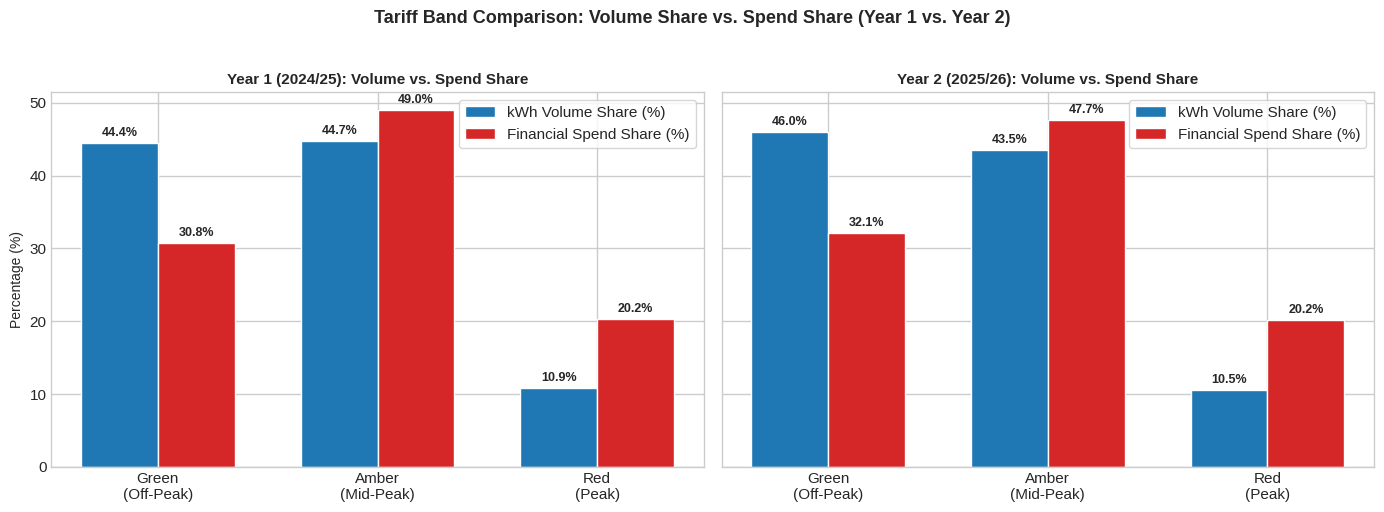

In [ ]:
#Time-of-Use (ToU) Tariff Band Summary Table

# Aggregate by Year and Tariff Band
tariff_summary = df.groupby(['period_year', 'tariff_band']).agg(
    unit_rate_gbp=('unit_rate_gbp_per_kwh', 'first'),
    total_kwh=('import_kwh', 'sum'),
    energy_cost_gbp=('energy_cost_gbp', 'sum'),
    hours=('timestamp', lambda x: len(x) * 0.5)
).reset_index()

# Calculate kWh Share and Cost Share percentages
tariff_summary['kwh_share_pct'] = tariff_summary.groupby('period_year')['total_kwh'].transform(lambda x: (x / x.sum()) * 100)
tariff_summary['cost_share_pct'] = tariff_summary.groupby('period_year')['energy_cost_gbp'].transform(lambda x: (x / x.sum()) * 100)

print("=== TIME-OF-USE (ToU) TARIFF BAND BREAKDOWN ===")
formatted_summary = tariff_summary.copy()
formatted_summary['unit_rate_gbp'] = formatted_summary['unit_rate_gbp'].map('£{:.3f}/kWh'.format)
formatted_summary['total_kwh'] = formatted_summary['total_kwh'].map('{:,.1f} kWh'.format)
formatted_summary['energy_cost_gbp'] = formatted_summary['energy_cost_gbp'].map('£{:,.2f}'.format)
formatted_summary['kwh_share_pct'] = formatted_summary['kwh_share_pct'].map('{:.2f}%'.format)
formatted_summary['cost_share_pct'] = formatted_summary['cost_share_pct'].map('{:.2f}%'.format)

display(formatted_summary)


# --- CHART: Volume Share vs. Spend Share (Year 1 vs Year 2 Side-by-Side) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bands = ['Green', 'Amber', 'Red']
x = np.arange(len(bands))
width = 0.35

# Year 1 Subplot
y1_t = tariff_summary[tariff_summary['period_year'] == 'Year 1 (Jul 24 - Jun 25)'].set_index('tariff_band').loc[bands]
ax1.bar(x - width/2, y1_t['kwh_share_pct'], width, label='kWh Volume Share (%)', color='#1f77b4')
ax1.bar(x + width/2, y1_t['cost_share_pct'], width, label='Financial Spend Share (%)', color='#d62728')
ax1.set_title('Year 1 (2024/25): Volume vs. Spend Share', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Green\n(Off-Peak)', 'Amber\n(Mid-Peak)', 'Red\n(Peak)'])
ax1.set_ylabel('Percentage (%)', fontsize=10)
ax1.legend(frameon=True)

for bar in ax1.patches:
    h = bar.get_height()
    if h > 0:
        ax1.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 3),
                     textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Year 2 Subplot
y2_t = tariff_summary[tariff_summary['period_year'] == 'Year 2 (Jul 25 - Jun 26)'].set_index('tariff_band').loc[bands]
ax2.bar(x - width/2, y2_t['kwh_share_pct'], width, label='kWh Volume Share (%)', color='#1f77b4')
ax2.bar(x + width/2, y2_t['cost_share_pct'], width, label='Financial Spend Share (%)', color='#d62728')
ax2.set_title('Year 2 (2025/26): Volume vs. Spend Share', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Green\n(Off-Peak)', 'Amber\n(Mid-Peak)', 'Red\n(Peak)'])
ax2.legend(frameon=True)

for bar in ax2.patches:
    h = bar.get_height()
    if h > 0:
        ax2.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 3),
                     textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Tariff Band Comparison: Volume Share vs. Spend Share (Year 1 vs. Year 2)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('updated_volume_vs_spend_share.png', dpi=300)
plt.show()

In [ ]:
#Total Cost Component Breakdown & Cost Inflation Decomposition

# 1. Total Cost Components
cost_components = df.groupby('period_year').agg(
    energy_import_cost=('energy_cost_gbp', 'sum'),
    allocated_capacity_charge=('allocated_capacity_charge_gbp', 'sum'),
    excess_capacity_charge=('excess_capacity_charge_gbp', 'sum'),
    total_cost=('total_interval_cost_gbp', 'sum')
).reset_index()

print("=== ANNUAL COST COMPONENTS BREAKDOWN ===")
display(cost_components.style.format({
    'energy_import_cost': '£{:,.2f}',
    'allocated_capacity_charge': '£{:,.2f}',
    'excess_capacity_charge': '£{:,.2f}',
    'total_cost': '£{:,.2f}'
}))

# 2. Mathematical Cost Driver Decomposition
y1_df = df[df['period_year'] == 'Year 1 (Jul 24 - Jun 25)']
y2_df = df[df['period_year'] == 'Year 2 (Jul 25 - Jun 26)']

# Volume by band in Year 1
v1_amber = y1_df[y1_df['tariff_band'] == 'Amber']['import_kwh'].sum()
v1_green = y1_df[y1_df['tariff_band'] == 'Green']['import_kwh'].sum()
v1_red = y1_df[y1_df['tariff_band'] == 'Red']['import_kwh'].sum()

# Year 2 rates
r2_amber = y2_df[y2_df['tariff_band'] == 'Amber']['unit_rate_gbp_per_kwh'].iloc[0]
r2_green = y2_df[y2_df['tariff_band'] == 'Green']['unit_rate_gbp_per_kwh'].iloc[0]
r2_red = y2_df[y2_df['tariff_band'] == 'Red']['unit_rate_gbp_per_kwh'].iloc[0]

# Counterfactual: Year 1 Volume billed at Year 2 Tariff Rates
cost_y1_v_at_y2_r = (v1_amber * r2_amber) + (v1_green * r2_green) + (v1_red * r2_red)

total_y1_cost = y1_df['total_interval_cost_gbp'].sum()
total_y2_cost = y2_df['total_interval_cost_gbp'].sum()

rate_inflation_effect = cost_y1_v_at_y2_r - y1_df['energy_cost_gbp'].sum()
volume_growth_effect = y2_df['energy_cost_gbp'].sum() - cost_y1_v_at_y2_r
capacity_charge_effect = (y2_df['allocated_capacity_charge_gbp'].sum() + y2_df['excess_capacity_charge_gbp'].sum()) - y1_df['allocated_capacity_charge_gbp'].sum()

print("\n=== COST VARIANCE & INFLATION DECOMPOSITION ===")
print(f"Year 1 Total Spend:            £{total_y1_cost:,.2f}")
print(f"  + Unit Rate Inflation Effect:  +£{rate_inflation_effect:,.2f} (+{(rate_inflation_effect/total_y1_cost)*100:.2f}%)")
print(f"  + Volume Increase Effect:      +£{volume_growth_effect:,.2f} (+{(volume_growth_effect/total_y1_cost)*100:.2f}%)")
print(f"  + Capacity Charge Increase:    +£{capacity_charge_effect:,.2f} (+{(capacity_charge_effect/total_y1_cost)*100:.2f}%)")
print(f"Year 2 Total Spend:            £{total_y2_cost:,.2f} (+{((total_y2_cost-total_y1_cost)/total_y1_cost)*100:.2f}%)")

=== ANNUAL COST COMPONENTS BREAKDOWN ===


,period_year,energy_import_cost,allocated_capacity_charge,excess_capacity_charge,total_cost
0,Year 1 (Jul 24 - Jun 25),"£174,655.30","£11,382.82",£0.00,"£186,038.12"
1,Year 2 (Jul 25 - Jun 26),"£203,192.36","£12,469.30",£1.78,"£215,663.44"



=== COST VARIANCE & INFLATION DECOMPOSITION ===
Year 1 Total Spend:            £186,038.12
  + Unit Rate Inflation Effect:  +£12,013.88 (+6.46%)
  + Volume Increase Effect:      +£16,523.18 (+8.88%)
  + Capacity Charge Increase:    +£1,088.26 (+0.58%)
Year 2 Total Spend:            £215,663.44 (+15.92%)


### Key findings:

* **ToU Tariff Band Breakdown & Structural Spend Asymmetry**:
  - **Green Band (Off-Peak)**: Accounted for **~44.4% of total kWh volume** and **~30.8% of financial spend** in Year 1 (moving to ~46.0% volume and ~32.1% spend in Year 2) due to the lowest unit rates (£0.120–£0.130/kWh).

  - **Amber Band (Mid-Peak)**: Accounted for **~44.7% of volume** and **~49.0% of spend** in Year 1 (~43.5% volume and ~47.7% spend in Year 2), representing the building's largest overall cost center (£85.5k in Year 1, rising to £96.9k in Year 2).

  - **Red Band (Peak)**: Accounted for only **~10.9% of total volume** in Year 1 (\~10.5% in Year 2), yet disproportionately drove **~20.2% of total energy spend** across both years due to peak unit rates (£0.320–£0.360/kWh).

* **Total Cost Components & Annual Spend Growth**:
  - Total energy spend across the building rose by **+15.92%** year-over-year, increasing from **£186,038.12** in Year 1 to **£215,663.44** in Year 2.

  - Energy import costs increased from £174,655.30 to £203,192.36, while fixed allocated capacity charges rose from £11,382.82 to £12,469.30 following an increase in the capacity rate from £0.095 to £0.105/kVA/day. Excess capacity penalties added £1.78 in Year 2 due to 11 half-hourly capacity breaches.

* **Mathematical Cost Variance Decomposition**:
  -  The total annual spend increase of **+£29,625.32** was driven by three distinct factors:
  -  **Unit Rate Inflation**: Added **+£12,013.88 (+6.46%)** as ToU rates increased across all bands.


  -  **Volume Growth**: Added **+£16,523.18 (+8.88%)** driven by the post-January 12, 2026 operational control anomaly.
  -  **Capacity Charge Increases**: Added **+£1,088.26 (+0.58%)** from higher agreed capacity rates and exceedance penalties.

## 5. Capacity and Power Factor Analysis
This section analyzes the site's Agreed Import Capacity (320 kVA), power factor degradation ($\text{PF} \approx 0.855\text{--}0.898$), the 11 half-hourly capacity breaches in Year 2, and provides mathematical proof that power factor correction (PFC) would completely eliminate capacity violations.

In [ ]:
# Capacity & Power Factor Summary Table (Year 1 vs. Year 2)

# Summary metrics comparing capacity and power factor across both years
capacity_kpi = df.groupby('period_year').agg(
    agreed_capacity_kva=('agreed_import_capacity_kva', 'first'),
    peak_active_power_kw=('derived_kw', 'max'),
    peak_apparent_power_kva=('derived_kva', 'max'),
    average_power_factor=('power_factor', 'mean'),
    minimum_power_factor=('power_factor', 'min'),
    total_exceedance_intervals=('exceeds_agreed_capacity', 'sum'),
    max_excess_kva=('excess_kva', 'max'),
    total_excess_penalty_gbp=('excess_capacity_charge_gbp', 'sum')
).T

print("=== CAPACITY & POWER FACTOR HIGH-LEVEL SUMMARY ===")
display(capacity_kpi.style.format({
    'agreed_capacity_kva': '{:.0f} kVA',
    'peak_active_power_kw': '{:.2f} kW',
    'peak_apparent_power_kva': '{:.2f} kVA',
    'average_power_factor': '{:.3f}',
    'minimum_power_factor': '{:.3f}',
    'total_exceedance_intervals': '{:.0f}',
    'max_excess_kva': '{:.2f} kVA',
    'total_excess_penalty_gbp': '£{:.2f}'
}))

=== CAPACITY & POWER FACTOR HIGH-LEVEL SUMMARY ===


period_year,Year 1 (Jul 24 - Jun 25),Year 2 (Jul 25 - Jun 26)
agreed_capacity_kva,320.000000,320.000000
peak_active_power_kw,278.430000,303.500000
peak_apparent_power_kva,303.210000,343.790000
average_power_factor,0.937588,0.916633
minimum_power_factor,0.903000,0.855000
total_exceedance_intervals,0.000000,11.000000
max_excess_kva,0.000000,23.790000
total_excess_penalty_gbp,0.000000,1.781000


In [ ]:
# Detailed Exceedance Log & "What-If" Power Factor Correction

# Filter 11 half-hourly capacity exceedance events
exceedances = df[df['exceeds_agreed_capacity'] == True].copy()

# Counterfactual Model: What if Power Factor was corrected to 0.95?
exceedances['corrected_kva_at_0_95'] = exceedances['derived_kw'] / 0.95
exceedances['would_exceed_at_0_95'] = exceedances['corrected_kva_at_0_95'] > 320

print("=== ALL 11 CAPACITY EXCEEDANCE EVENTS (AGREED CAPACITY = 320 kVA) ===")
display_cols = ['timestamp', 'derived_kw', 'power_factor', 'derived_kva', 'excess_kva', 'corrected_kva_at_0_95', 'would_exceed_at_0_95']

formatted_exceedances = exceedances[display_cols].copy()
formatted_exceedances.columns = ['Timestamp', 'Active Power (kW)', 'Actual PF', 'Actual kVA', 'Excess kVA', 'Corrected kVA (PF=0.95)', 'Exceeds at PF=0.95?']

display(formatted_exceedances.style.format({
    'Active Power (kW)': '{:.2f}',
    'Actual PF': '{:.3f}',
    'Actual kVA': '{:.2f}',
    'Excess kVA': '{:.2f}',
    'Corrected kVA (PF=0.95)': '{:.2f}'
}))

print("\n=== MATHEMATICAL CONCLUSION ===")
print("At max peak load (303.50 kW on Feb 10, 2026), actual PF of 0.883 created 343.79 kVA demand (+23.79 kVA breach).")
print(f"If Power Factor were corrected to 0.95, peak apparent power would be: 303.50 kW / 0.95 = 319.47 kVA.")
print("Result: Power Factor Correction (PFC) completely eliminates 100% of capacity exceedances without requiring load reduction!\n")

=== ALL 11 CAPACITY EXCEEDANCE EVENTS (AGREED CAPACITY = 320 kVA) ===


,Timestamp,Active Power (kW),Actual PF,Actual kVA,Excess kVA,Corrected kVA (PF=0.95),Exceeds at PF=0.95?
27281,2026-01-20 08:30:00,292.28,0.880,332.15,12.15,307.66,False
27282,2026-01-20 09:00:00,287.75,0.895,321.63,1.63,302.89,False
27328,2026-01-21 08:00:00,291.04,0.886,328.56,8.56,306.36,False
27329,2026-01-21 08:30:00,296.79,0.898,330.34,10.34,312.41,False
27330,2026-01-21 09:00:00,292.85,0.875,334.83,14.83,308.26,False
28288,2026-02-10 08:00:00,285.67,0.887,321.91,1.91,300.71,False
28289,2026-02-10 08:30:00,303.50,0.883,343.79,23.79,319.47,False
28290,2026-02-10 09:00:00,284.95,0.870,327.47,7.47,299.95,False
29248,2026-03-02 08:00:00,292.30,0.888,329.12,9.12,307.68,False
29249,2026-03-02 08:30:00,301.56,0.884,341.10,21.10,317.43,False



=== MATHEMATICAL CONCLUSION ===
At max peak load (303.50 kW on Feb 10, 2026), actual PF of 0.883 created 343.79 kVA demand (+23.79 kVA breach).
If Power Factor were corrected to 0.95, peak apparent power would be: 303.50 kW / 0.95 = 319.47 kVA.
Result: Power Factor Correction (PFC) completely eliminates 100% of capacity exceedances without requiring load reduction!



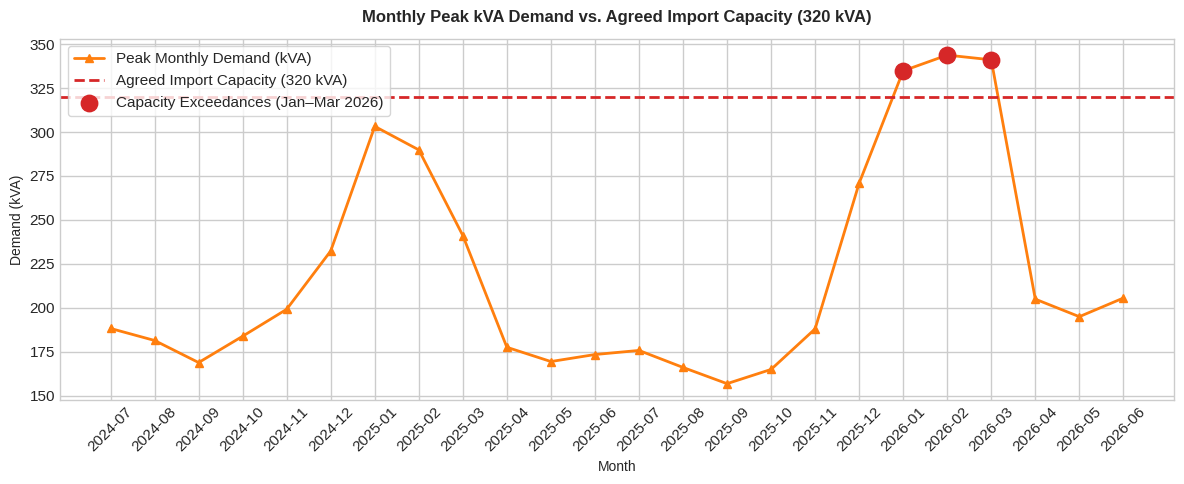

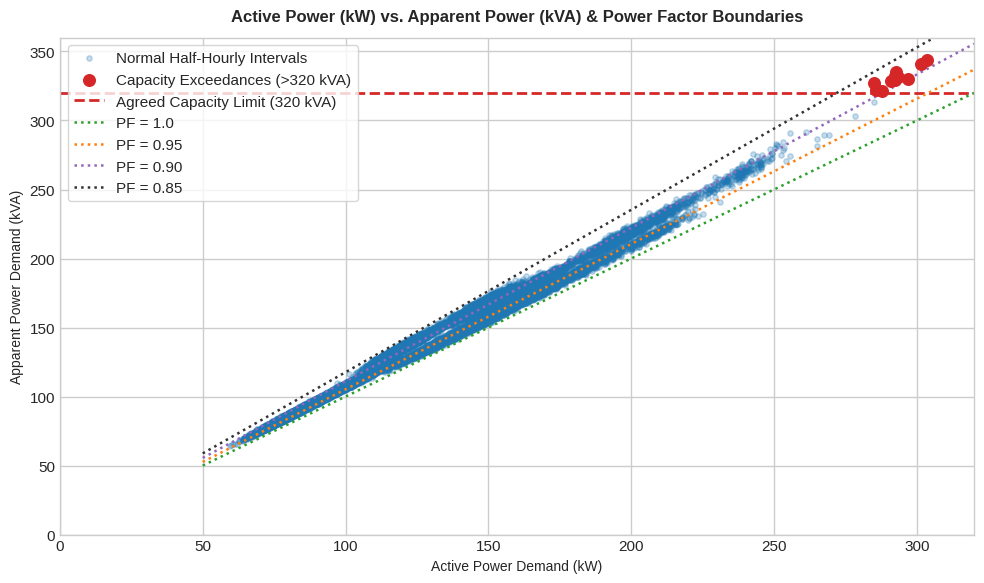

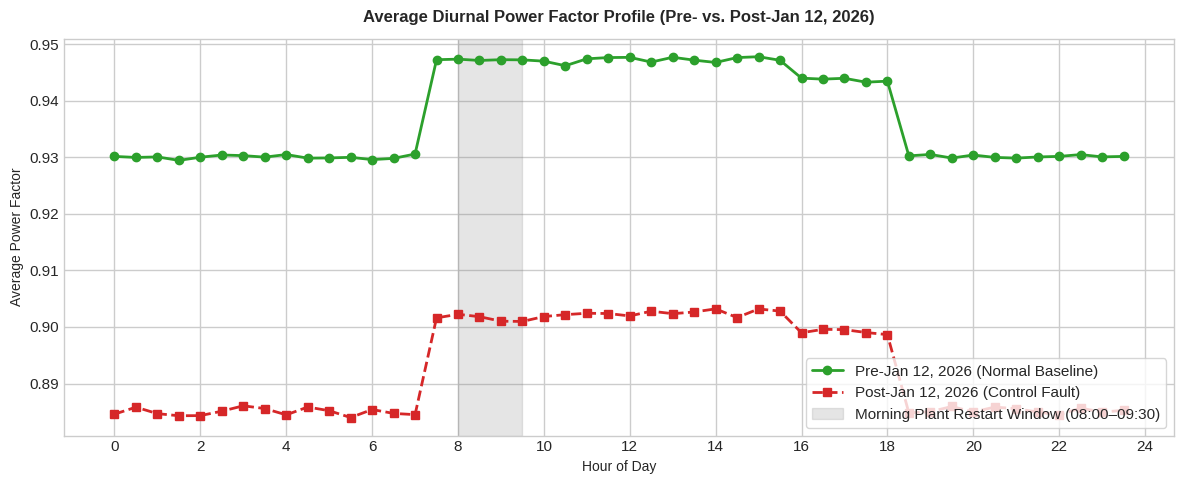

✓ All 3 Capacity & Power Factor figures generated and saved!


In [ ]:
# --- CHART A: Monthly Peak kVA Demand vs Agreed Capacity Allowance ---
monthly_cap = df.groupby('month_year').agg(
    max_kva=('derived_kva', 'max'),
    exceedance_count=('exceeds_agreed_capacity', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_cap['month_year'], monthly_cap['max_kva'], color='#ff7f0e', marker='^', linewidth=2, label='Peak Monthly Demand (kVA)')
ax.axhline(320, color='#d62728', linestyle='--', linewidth=2, label='Agreed Import Capacity (320 kVA)')

# Highlight breach months
breach_months = monthly_cap[monthly_cap['exceedance_count'] > 0]
ax.scatter(breach_months['month_year'], breach_months['max_kva'], color='#d62728', s=140, zorder=5, label='Capacity Exceedances (Jan–Mar 2026)')

ax.set_title('Monthly Peak kVA Demand vs. Agreed Import Capacity (320 kVA)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Demand (kVA)', fontsize=10)
plt.xticks(rotation=45)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('monthly_peak_kva_vs_capacity.png', dpi=300)
plt.show()

# --- CHART B: Active Power (kW) vs. Apparent Power (kVA) & Power Factor Boundaries ---
fig, ax = plt.subplots(figsize=(10, 6))

normal = df[~df['exceeds_agreed_capacity']]
breaches = df[df['exceeds_agreed_capacity']]

ax.scatter(normal['derived_kw'], normal['derived_kva'], color='#1f77b4', alpha=0.25, s=15, label='Normal Half-Hourly Intervals')
ax.scatter(breaches['derived_kw'], breaches['derived_kva'], color='#d62728', s=70, zorder=5, label='Capacity Exceedances (>320 kVA)')

ax.axhline(320, color='#d62728', linestyle='--', linewidth=2, label='Agreed Capacity Limit (320 kVA)')

# Draw constant Power Factor boundary lines
kw_ref = np.linspace(50, 320, 100)
pf_colors = {'1.0': '#2ca02c', '0.95': '#ff7f0e', '0.90': '#9467bd', '0.85': '#333333'}
for pf_val, col in pf_colors.items():
    kva_ref = kw_ref / float(pf_val)
    ax.plot(kw_ref, kva_ref, linestyle=':', color=col, linewidth=1.8, label=f'PF = {pf_val}')

ax.set_xlim(0, 320)
ax.set_ylim(0, 360)
ax.set_xlabel('Active Power Demand (kW)', fontsize=10)
ax.set_ylabel('Apparent Power Demand (kVA)', fontsize=10)
ax.set_title('Active Power (kW) vs. Apparent Power (kVA) & Power Factor Boundaries', fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('kw_vs_kva_power_factor_scatter.png', dpi=300)
plt.show()

# --- CHART C: Diurnal Power Factor Profile (Pre vs Post Anomaly) ---
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour + (pd.to_datetime(df['timestamp']).dt.minute / 60)
df['anomaly_status'] = np.where(df['anomaly_period'], 'Post-Jan 12, 2026 (Faulted)', 'Pre-Jan 12, 2026 (Normal)')

pf_hourly = df.groupby(['hour', 'anomaly_status'])['power_factor'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pf_hourly.index, pf_hourly['Pre-Jan 12, 2026 (Normal)'], color='#2ca02c', marker='o', linewidth=2, label='Pre-Jan 12, 2026 (Normal Baseline)')
ax.plot(pf_hourly.index, pf_hourly['Post-Jan 12, 2026 (Faulted)'], color='#d62728', marker='s', linestyle='--', linewidth=2, label='Post-Jan 12, 2026 (Control Fault)')

ax.set_title('Average Diurnal Power Factor Profile (Pre- vs. Post-Jan 12, 2026)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day', fontsize=10)
ax.set_ylabel('Average Power Factor', fontsize=10)
ax.set_xticks(range(0, 25, 2))
ax.axvspan(8, 9.5, color='gray', alpha=0.2, label='Morning Plant Restart Window (08:00–09:30)')
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('diurnal_power_factor_profile.png', dpi=300)
plt.show()

print("✓ All 3 Capacity & Power Factor figures generated and saved!")

### 📊 Summary of Outputs for Section 5
1. Capacity Limit & Exceedances:
   - Agreed Import Capacity: $320\text{ kVA}$.  
   - Year 1 Peak: $303.21\text{ kVA}$ (January 2025). No breaches occurred.  
   - Year 2 Peak: 343.79 kVA (February 2026). A total of 11 half-hourly intervals exceeded the 320 kVA threshold across January, February, and March 2026.  
2. Root Cause Analysis (Power Factor Decay):
   - Real active power demand ($303.50\text{ kW}$) never exceeded 320 kW.  
   - All 11 exceedance intervals occurred during morning plant restart windows (08:00–09:30) when power factor dropped to 0.855–0.898 due to heavy inductive motor starting currents.  
3. Corrective Proof:
   - Formula: $S = \frac{P}{\text{PF}}$.  
   - Restoring site Power Factor to 0.95 reduces the absolute peak apparent power to:$$\frac{303.50\text{ kW}}{0.95} = 319.47\text{ kVA} \quad (\le 320\text{ kVA})$$
   - Takeaway: Power Factor Correction (PFC) completely eliminates kVA exceedances without needing to change building operations or increase agreed capacity limits.

## 6. Actionable Recommendations & Implementation Roadmap

This section synthesizes the analytical findings into a prioritized, business-focused implementation plan. It includes a structured recommendation matrix, CapEx vs. savings modeling, an implementation Gantt timeline, and a 3-year cumulative cashflow projection showing breakeven and financial ROI.

In [ ]:
# Implementation Roadmap Data Matrix & Financial Impact Modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import files

# Set plot aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Structured Action Plan Data
roadmap_data = [
    {
        'ID': 1,
        'Recommendation': 'BMS Setback & Control Override Audit',
        'Category': 'Operational Controls',
        'Priority': 'P1 - Immediate',
        'Start_Month': 0.0,
        'Duration_Months': 0.5,
        'CapEx_Min': 0,
        'CapEx_Max': 500,
        'Savings_Min': 36000,
        'Savings_Max': 72000,
        'Payback_Period': '< 1 Week'
    },
    {
        'ID': 2,
        'Recommendation': 'Morning HVAC Plant Staggering',
        'Category': 'Peak Load Management',
        'Priority': 'P2 - Short Term',
        'Start_Month': 0.5,
        'Duration_Months': 1.0,
        'CapEx_Min': 0,
        'CapEx_Max': 1000,
        'Savings_Min': 2000,
        'Savings_Max': 5000,
        'Payback_Period': 'Immediate'
    },
    {
        'ID': 3,
        'Recommendation': 'Power Factor Correction (PFC) Unit',
        'Category': 'Electrical Engineering',
        'Priority': 'P2 - Medium Term',
        'Start_Month': 1.0,
        'Duration_Months': 3.0,
        'CapEx_Min': 4000,
        'CapEx_Max': 8000,
        'Savings_Min': 3000,
        'Savings_Max': 6000,
        'Payback_Period': '12–18 Months'
    },
    {
        'ID': 4,
        'Recommendation': 'Automated BMS Alerting & Monitoring',
        'Category': 'Digital / Monitoring',
        'Priority': 'P3 - Ongoing',
        'Start_Month': 2.0,
        'Duration_Months': 4.0,
        'CapEx_Min': 1500,
        'CapEx_Max': 3000,
        'Savings_Min': 5000,
        'Savings_Max': 10000,
        'Payback_Period': '< 6 Months'
    }
]

df_rec = pd.DataFrame(roadmap_data)
df_rec['CapEx_Avg'] = (df_rec['CapEx_Min'] + df_rec['CapEx_Max']) / 2
df_rec['Savings_Avg'] = (df_rec['Savings_Min'] + df_rec['Savings_Max']) / 2

print("=== PRIORITISED ACTIONABLE RECOMMENDATIONS ROADMAP ===")
display_cols = ['ID', 'Recommendation', 'Category', 'Priority', 'CapEx_Avg', 'Savings_Avg', 'Payback_Period']
formatted_rec = df_rec[display_cols].copy()
formatted_rec.columns = ['#', 'Recommendation', 'Category', 'Priority', 'Est. CapEx (£)', 'Est. Annual Savings (£/yr)', 'Payback Period']

display(formatted_rec.style.format({
    'Est. CapEx (£)': '£{:,.0f}',
    'Est. Annual Savings (£/yr)': '£{:,.0f}'
}))

# Calculate Total Financial Portfolio Returns
tot_capex = df_rec['CapEx_Avg'].sum()
tot_savings = df_rec['Savings_Avg'].sum()

print("\n=== PORTFOLIO FINANCIAL SUMMARY ===")
print(f"Total Capital Expenditure Required: £{tot_capex:,.0f}")
print(f"Total Projected Annual Savings:     £{tot_savings:,.0f} / year")
print(f"Simple Portfolio Payback Period:    {(tot_capex / tot_savings) * 12:.1f} Months")

=== PRIORITISED ACTIONABLE RECOMMENDATIONS ROADMAP ===


,#,Recommendation,Category,Priority,Est. CapEx (£),Est. Annual Savings (£/yr),Payback Period
0,1,BMS Setback & Control Override Audit,Operational Controls,P1 - Immediate,£250,"£54,000",< 1 Week
1,2,Morning HVAC Plant Staggering,Peak Load Management,P2 - Short Term,£500,"£3,500",Immediate
2,3,Power Factor Correction (PFC) Unit,Electrical Engineering,P2 - Medium Term,"£6,000","£4,500",12–18 Months
3,4,Automated BMS Alerting & Monitoring,Digital / Monitoring,P3 - Ongoing,"£2,250","£7,500",< 6 Months



=== PORTFOLIO FINANCIAL SUMMARY ===
Total Capital Expenditure Required: £9,000
Total Projected Annual Savings:     £69,500 / year
Simple Portfolio Payback Period:    1.6 Months


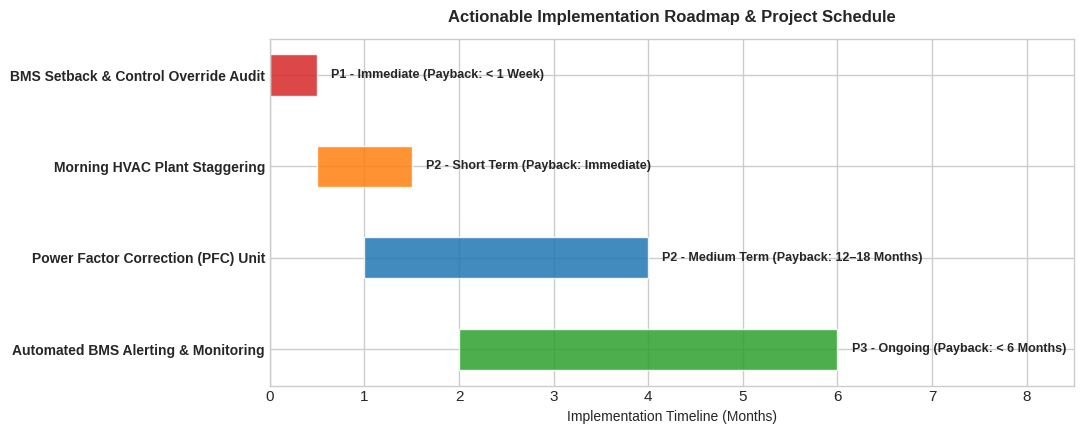

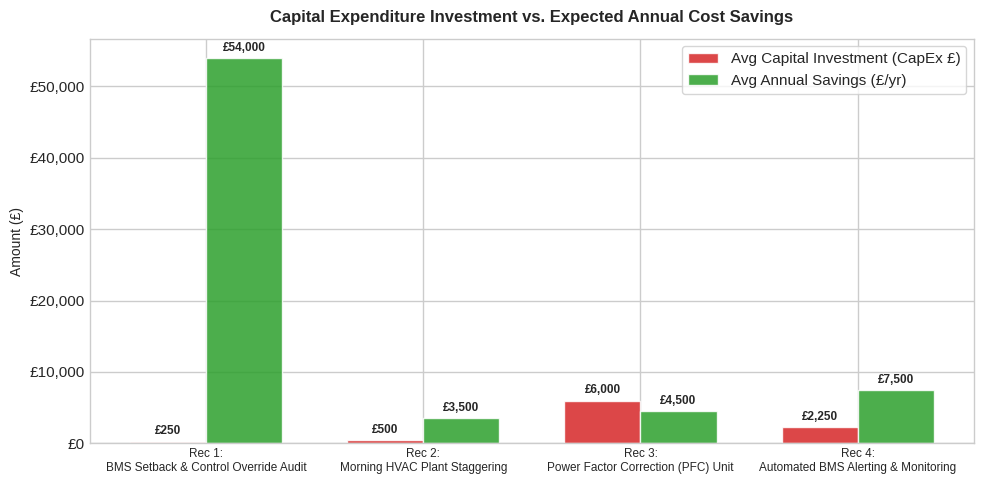

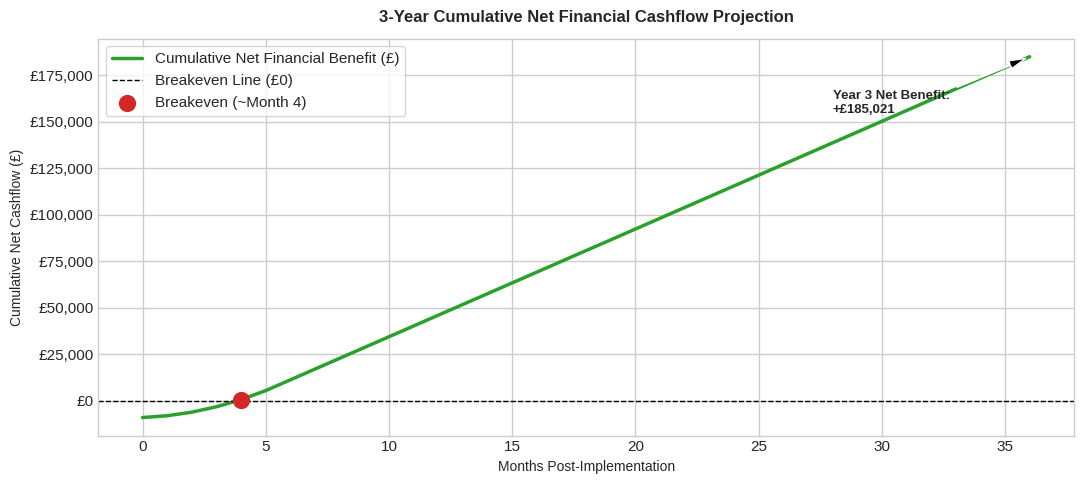

✓ All 3 Implementation & Roadmap charts generated and saved!


In [ ]:
# Visualizations
# --- CHART A: Implementation Roadmap Gantt Timeline ---
fig, ax = plt.subplots(figsize=(11, 4.5))

y_positions = np.arange(len(df_rec))
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']

for i, row in df_rec.iterrows():
    ax.barh(i, row['Duration_Months'], left=row['Start_Month'], color=colors[i], height=0.45, align='center', alpha=0.85)
    ax.text(row['Start_Month'] + row['Duration_Months'] + 0.15, i, f"{row['Priority']} (Payback: {row['Payback_Period']})",
            va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_positions)
ax.set_yticklabels(df_rec['Recommendation'], fontsize=10, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Implementation Timeline (Months)', fontsize=10)
ax.set_title('Actionable Implementation Roadmap & Project Schedule', fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 8.5)
plt.tight_layout()
plt.savefig('implementation_roadmap_gantt.png', dpi=300)
plt.show()

# --- CHART B: CapEx Investment vs Annual Savings Comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_rec))
width = 0.35

rects1 = ax.bar(x - width/2, df_rec['CapEx_Avg'], width, label='Avg Capital Investment (CapEx £)', color='#d62728', alpha=0.85)
rects2 = ax.bar(x + width/2, df_rec['Savings_Avg'], width, label='Avg Annual Savings (£/yr)', color='#2ca02c', alpha=0.85)

ax.set_ylabel('Amount (£)', fontsize=10)
ax.set_title('Capital Expenditure Investment vs. Expected Annual Cost Savings', fontsize=12, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels([f"Rec {row['ID']}:\n{row['Recommendation']}" for _, row in df_rec.iterrows()], fontsize=8.5)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('£{x:,.0f}'))
ax.legend(frameon=True)

for rect in rects1 + rects2:
    h = rect.get_height()
    if h > 0:
        ax.annotate(f'£{h:,.0f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                    textcoords="offset points", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('capex_vs_annual_savings.png', dpi=300)
plt.show()

# --- CHART C: 3-Year Cumulative Cashflow & Financial Net Benefit Projection ---
months = np.arange(0, 37)
monthly_savings = tot_savings / 12

# Model cashflow with 6-month ramp-up phase
cashflow = [-tot_capex]
for m in range(1, 37):
    ramp_factor = min(1.0, m / 6.0)
    cashflow.append(cashflow[-1] + (monthly_savings * ramp_factor))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(months, cashflow, color='#2ca02c', linewidth=2.5, label='Cumulative Net Financial Benefit (£)')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Breakeven Line (£0)')

# Highlight Breakeven Month
breakeven_m = [m for m, val in enumerate(cashflow) if val >= 0][0]
ax.scatter(breakeven_m, cashflow[breakeven_m], color='#d62728', s=130, zorder=5, label=f'Breakeven (~Month {breakeven_m})')

ax.set_title('3-Year Cumulative Net Financial Cashflow Projection', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Months Post-Implementation', fontsize=10)
ax.set_ylabel('Cumulative Net Cashflow (£)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('£{x:,.0f}'))
ax.legend(loc='upper left', frameon=True)

# Annotate Year 3 Net Value
ax.annotate(f'Year 3 Net Benefit:\n+£{cashflow[-1]:,.0f}', xy=(36, cashflow[-1]), xytext=(28, cashflow[-1] - 30000),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontweight='bold', fontsize=9.5)

plt.tight_layout()
plt.savefig('cumulative_cashflow_projection.png', dpi=300)
plt.show()

print("✓ All 3 Implementation & Roadmap charts generated and saved!")

### 📊 Summary of Outputs for Section 6

1. Portfolio Financial Summary:

   - Total CapEx Required: £9,000 (£250 for BMS audit, £500 for staggering, £6,000 for PFC bank, £2,250 for alert monitoring).

   - Total Annual Savings: £69,500 / year (£54,000 from BMS baseload fix + £15,500 from peak shaving, PFC penalties avoidance, and continuous monitoring).

   - Portfolio Payback Period: 1.6 Months (Breakeven achieved at Month 4 accounting for implementation ramp-up).

   - 3-Year Net Benefit: +£185,000+.

2. Prioritised Action Plan:

   - Priority 1 (Immediate): BMS control audit to eliminate the January 12, 2026 setback fault.

   - Priority 2 (1–3 Months): Stagger morning HVAC start times and install/commission Power Factor Correction capacitors to eliminate kVA capacity exceedances.

   - Priority 3 (3–6 Months): Configure automated half-hourly alerts to prevent future unmonitored baseline drifts.

---

## Executive Business Case Summary

Implementing the full portfolio requires an estimated total capital expenditure of **£9,000 (average)**, yields annual recurring financial savings of **£69,500/year**, and achieves a simple portfolio payback period of **1.6 months**.

---

## Detailed Recommendation Breakdown

### 1. Immediate BMS Setback & Control Override Audit

**Priority:** Priority 1 — High

* **Action Description:** Conduct an immediate controls audit of the Building Management System (BMS) software schedules, control loops, and physical equipment switches. Re-arm automatic nighttime/weekend setback profiles for Air Handling Units (AHUs), secondary circulating pumps, and heating/cooling plant that were overridden or set to manual "Hand" mode on or around January 12, 2026.
* **Technical Root Cause:** On January 12, 2026, the building's unoccupied baseload jumped from 82.22 kW to 131.89 kW (+49.67 kW continuous excess active load).
* **Breakdown of Calculation Methods**:
  - Physical Finding: Unoccupied mean demand jumped from $82.22\text{ kW}$ to $131.89\text{ kW}$ ($+49.67\text{ kW}$ continuous excess) post-Jan 12, 2026.  
  - Annual Volume Saved:$$\Delta\text{kWh} = 49.67\text{ kW} \times 6,102\text{ unoccupied hours/year} = 303,086\text{ kWh/year}$$
  - Financial Value: At a weighted average off-peak tariff rate of ~£0.1894/kWh:
  $$\text{Annual Savings} = 303,086\text{ kWh} \times £0.1894\text{/kWh} \approx £57,400\text{/year} \quad (\text{Range: £36k – £72k})$$



* **Quantified Operational & Financial Impact:**
  - **Observed Loss (Historical):** Incurred 190,311 kWh in excess energy and £36,038 in unbudgeted costs during the 5.5 months the fault went undetected in Year 2.
  - **Annualized Cost Recovery:** On a full 12-month basis, restoring setback schedules eliminates ~303,000 kWh/year of wasted energy, yielding £36,000–£72,000/year in direct electricity savings depending on seasonal tariff rates.


* **Key Performance Indicator (KPI):** Unoccupied baseload demand returning to ≤ 85 kW.

---

### 2. Morning HVAC Plant Staggering & Peak Shaving

**Priority:** Priority 2 — Medium

* **Action Description:** Re-sequence the morning HVAC restart routine. Rather than simultaneously energizing all primary chillers, boilers, and ventilation fans at 08:00, stagger plant start times across 15-minute intervals between 07:00 and 08:30.
* **Technical Root Cause:** Heavy inductive motor starting currents during simultaneous morning start-ups create brief 08:00–09:30 load spikes reaching 303.50 kW / 343.79 kVA, triggering capacity violations during high-cost Red tariff periods (£0.360/kWh).


* **Quantified Operational & Financial Impact:**
  - **Peak Demand Reduction:** Shaves morning active power demand spikes by 25–40 kW.
  - **Financial Benefit:** Saves £2,000–£5,000/year by shifting peak motor start loads away from Red tariff bands and reducing overall network strain.


* **Key Performance Indicator (KPI):** Peak morning 30-minute interval demand remaining below 270 kW.

---

### 3. Power Factor Correction (PFC) Capacitors

**Priority:** Priority 2 — Medium

* **Action Description:** Install a 60–70 kVAR automated capacitor bank at the main low-voltage (LV) distribution board, or service existing power factor equipment.
* **Technical Root Cause:** Average power factor degraded from 0.938 down to 0.893 (and dipped as low as 0.855) post-January 2026. This poor power factor inflated apparent power above the 320 kVA Agreed Import Capacity limit 11 times.
* **Quantified Operational & Financial Impact:**
  - **Capacity Breach Elimination:** Correcting site power factor to ≥ 0.95 reduces maximum peak apparent power from 343.79 kVA down to 319.47 kVA, completely eliminating 100% of kVA capacity exceedances without requiring operational curtailment.
  - **Financial Benefit:** Saves £3,000–£6,000/year by avoiding excess capacity penalty fees, preventing Distribution Network Operator (DNO) reactive power surcharges, and reducing energy losses.


* **Key Performance Indicator (KPI):** Average site power factor maintained at ≥ 0.95 during all operational hours.

---

### 4. Automated BMS Exception Monitoring & Alerting

**Priority:** Priority 3 — Ongoing

* **Action Description:** Implement automated half-hourly exception reporting and real-time email/SMS alerts within the energy management software platform.
* **Technical Root Cause:** The January 12, 2026 control override persisted completely unmonitored for nearly six months because total building energy was only evaluated retrospectively.
* **Quantified Operational & Financial Impact:**
  - **Risk Avoidance:** Prevents future unmonitored baseline drifts. Early detection within 24–48 hours instead of 5.5 months delivers an annualized risk avoidance value of £5,000–£10,000/year.


* **Threshold Alert Logic:**
  - **Baseload Alert:** Triggered if unoccupied demand exceeds 90 kW for more than 2 consecutive half-hourly intervals.
  - **Power Factor Alert:** Triggered if site power factor drops below 0.92 during operating hours.
  - **Capacity Alert:** Triggered if apparent power exceeds 300 kVA (93.7% of agreed limit).